<a href="https://colab.research.google.com/github/EmiiFernandez/actividades_data_sciente_ypf/blob/main/notebook/C16_Notebook-20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

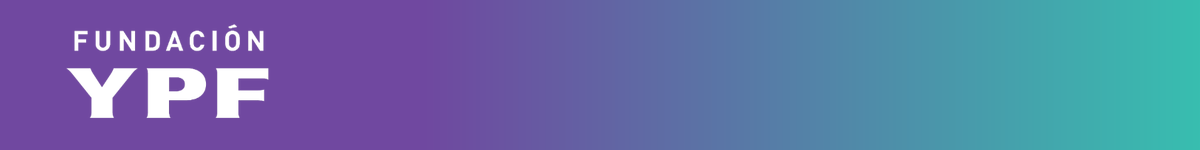

# Fundación YPF - Data Science

## Notebook 20 C16: Validación cruzada y optimización de hiperparámetros

### Índice

* **Parte 0.** Repaso y preparación de los datos (cáncer mamario).
* **Parte 1.** El problema de una única partición train/test.
* **Parte 2.** Validación cruzada K-Fold: a mano y con `cross_val_score`.
* **Parte 3.** Stratified K-Fold, métricas múltiples y elección de K.
* **Parte 4.** Pipelines dentro de la validación cruzada y comparación de modelos.
* **Parte 5.** Optimización de hiperparámetros: curva de validación, `GridSearchCV` y `RandomizedSearchCV`.
* **Parte 6.** Ejercicio para las salas de Zoom (expectativa de vida).
* **Anexo.** Soluciones sugeridas de la Parte 6.

### Cómo se usa esta notebook

La clase se recorre en sala general de la Parte 0 a la Parte 5, con el dataset de cáncer mamario. La Parte 6 se trabaja en las salas de Zoom con un dataset distinto (expectativa de vida) y el Anexo trae las soluciones sugeridas para la puesta en común.

Esta notebook retoma tres cosas de las clases anteriores:

* La separación en entrenamiento y test y el uso de `Pipeline` (clases 8, 9 y 12).
* Las métricas de la clase 15: exactitud, F1, curva ROC y AUC para clasificación, y MAE y R² para regresión.
* El dataset de cáncer mamario de las Notebooks 16 y 17, donde los modelos no superaban por mucho al piso. Hoy vamos a poder responder con más rigor si esas diferencias eran reales o si eran producto de la partición.

**Datasets que necesita:** `cancer_mamario.csv` y `life_expectancy_data.csv`. Tienen que estar en `/content/` si se trabaja en Colab, o en la misma carpeta que la notebook si se trabaja de forma local.

## Parte 0. Repaso y preparación de los datos

Cargamos las librerías y el dataset de cáncer mamario. Cada fila es una paciente y la variable a predecir es si el cáncer **reapareció** (`recurrence-events`) o no (`no-recurrence-events`).

In [ ]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import randint

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import (
    GridSearchCV, KFold, ParameterGrid, RandomizedSearchCV, RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_score, cross_validate, train_test_split, validation_curve,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8, 4)
SEMILLA = 42

In [ ]:
def leer_csv(nombre):
    """Lee un CSV desde /content/ (Colab) y, si no existe, desde el directorio local."""
    try:
        return pd.read_csv("/content/" + nombre)
    except FileNotFoundError:
        return pd.read_csv(nombre)


df = leer_csv("cancer_mamario.csv")
print(df.shape)
df.head()

### Limpieza

El dataset marca los faltantes con el texto `"?"`. Lo reemplazamos por `NaN` para que pandas y scikit-learn los reconozcan como faltantes.

In [ ]:
df = df.replace("?", np.nan)
print(df.isna().sum()[df.isna().sum() > 0])

### Variable objetivo y variables predictoras

Definimos `y = 1` cuando hubo recurrencia. Después de armar `y` la sacamos de `X`.

In [ ]:
y = (df["class"] == "recurrence-events").astype(int)
X = df.drop(columns="class")

print("Proporción de recurrencias:", round(y.mean(), 3))
print("Exactitud de un modelo que siempre dice 'no hay recurrencia':", round(1 - y.mean(), 3))

Este número es el **piso** que ya conocemos: un modelo que no aprende nada acierta el 70% de las veces. Por eso, en esta notebook vamos a mirar también el **F1** y el **AUC** (clase 15) y no solamente la exactitud.

### Preprocesamiento

Todas las variables son categóricas salvo `deg-malig`. Tres de ellas son **rangos con orden** (`age`, `tumor-size`, `inv-nodes`) y las codificamos con `OrdinalEncoder` respetando ese orden. Las demás son categorías sin orden y van con `OneHotEncoder`, después de imputar los faltantes con la categoría más frecuente.

Todo esto queda dentro de un `ColumnTransformer`, que después vamos a meter dentro de un `Pipeline`. Esa decisión es central para la clase de hoy y la vamos a justificar en la Parte 4.

In [ ]:
ORDEN_EDAD = ["20-29", "30-39", "40-49", "50-59", "60-69", "70-79"]
ORDEN_TUMOR = ["0-4", "5-9", "10-14", "15-19", "20-24", "25-29", "30-34",
               "35-39", "40-44", "45-49", "50-54"]
ORDEN_GANGLIOS = ["0-2", "3-5", "6-8", "9-11", "12-14", "15-17", "18-20", "21-23", "24-26"]

preprocesador = ColumnTransformer([
    ("ordinales", OrdinalEncoder(categories=[ORDEN_EDAD, ORDEN_TUMOR, ORDEN_GANGLIOS]),
     ["age", "tumor-size", "inv-nodes"]),
    ("nominales", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), ["menopause", "node-caps", "breast", "breast-quad", "irradiat"]),
    ("numericas", "passthrough", ["deg-malig"]),
])

### Separación en entrenamiento y test

Separamos el test **una sola vez**, ahora, y no lo vamos a tocar hasta el final de la Parte 5. Todo lo que hagamos en el medio (comparar modelos, elegir hiperparámetros) se hace con validación cruzada sobre `X_train`.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEMILLA
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Recurrencias en train:", round(y_train.mean(), 3), "| en test:", round(y_test.mean(), 3))

## Parte 1. El problema de una única partición

Entrenamos un árbol de decisión de profundidad 3 (el de las Notebooks 14 y 16) y lo evaluamos con una partición train/test. La pregunta es: **¿cuánto depende ese resultado de qué filas cayeron en test?**

Para averiguarlo repetimos el mismo procedimiento 200 veces, cambiando solamente la semilla del `train_test_split`.

Este experimento usa todos los datos con fines ilustrativos y no toma ninguna decisión de modelado, así que no contamina el test que separamos en la Parte 0.

In [ ]:
arbol = Pipeline([
    ("prep", preprocesador),
    ("clf", DecisionTreeClassifier(max_depth=3, random_state=SEMILLA)),
])

exactitudes = []
for semilla in range(200):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=semilla
    )
    exactitudes.append(clone(arbol).fit(X_tr, y_tr).score(X_te, y_te))
exactitudes = np.array(exactitudes)

print(f"Media: {exactitudes.mean():.3f}")
print(f"Desvío: {exactitudes.std():.3f}")
print(f"Mínimo: {exactitudes.min():.3f} | Máximo: {exactitudes.max():.3f}")

In [ ]:
plt.hist(exactitudes, bins=15, color="#753BAE", edgecolor="white")
plt.axvline(exactitudes.mean(), color="#38BEB0", linewidth=2, label="Media")
plt.xlabel("Exactitud en test")
plt.ylabel("Cantidad de particiones")
plt.title("Mismo modelo, mismos datos, 200 particiones distintas")
plt.legend()
plt.show()

**Para discutir:** el modelo es exactamente el mismo y los datos también. Lo único que cambió es qué 72 filas cayeron en test, y la exactitud recorre un rango de casi 20 puntos. Si hubiéramos usado una sola semilla, podríamos haber informado un 61% o un 81% y ambos habrían sido "correctos".

La validación cruzada resuelve esto de la siguiente manera: en lugar de una partición, hacemos K y promediamos.

## Parte 2. Validación cruzada K-Fold

Trabajamos ahora **solamente con `X_train`**. El procedimiento es el de la teoría:

1. Mezclar los datos.
2. Separarlos en K folds del mismo tamaño.
3. Para cada fold: usarlo como validación, entrenar con los otros K-1, evaluar y guardar el resultado.
4. Promediar los K resultados y mirar también su desvío.

Primero miramos cómo `KFold` reparte los índices con K = 5.

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEMILLA)

for i, (idx_train, idx_val) in enumerate(kf.split(X_train), start=1):
    print(f"Fold {i}: entrena con {len(idx_train)} filas, valida con {len(idx_val)}")

### K-Fold a mano

Escribimos el ciclo completo para ver que no hay magia. En cada vuelta partimos de un modelo **sin entrenar** (`clone`), lo ajustamos con los K-1 folds de entrenamiento y lo evaluamos con el fold que quedó afuera.

In [ ]:
scores_manual = []
for idx_train, idx_val in kf.split(X_train):
    modelo = clone(arbol)
    modelo.fit(X_train.iloc[idx_train], y_train.iloc[idx_train])
    scores_manual.append(modelo.score(X_train.iloc[idx_val], y_train.iloc[idx_val]))

print("Exactitud por fold:", np.round(scores_manual, 3))
print(f"Promedio: {np.mean(scores_manual):.3f} | Desvío: {np.std(scores_manual):.3f}")

### Lo mismo con `cross_val_score`

Scikit-learn hace ese ciclo por nosotros. Con el mismo `KFold` tiene que dar exactamente los mismos números.

In [ ]:
scores = cross_val_score(arbol, X_train, y_train, cv=kf)  # por defecto usa la exactitud

print("Exactitud por fold:", np.round(scores, 3))
print(f"Promedio: {scores.mean():.3f} | Desvío: {scores.std():.3f}")
print("Coincide con el ciclo a mano:", np.allclose(scores, scores_manual))

### Un piso también se evalúa con validación cruzada

Antes de sacar conclusiones, medimos el modelo que siempre responde "no hay recurrencia" con el mismo procedimiento.

In [ ]:
piso = DummyClassifier(strategy="most_frequent")
scores_piso = cross_val_score(piso, X_train, y_train, cv=kf)
print(f"Piso: {scores_piso.mean():.3f} ± {scores_piso.std():.3f}")
print(f"Árbol de profundidad 3: {scores.mean():.3f} ± {scores.std():.3f}")

**Para discutir:** la diferencia entre el árbol y el piso es chica comparada con el desvío entre folds. La exactitud no alcanza para decir si el árbol aprendió algo, porque el piso ya acierta la mayoría de las veces. En la Parte 3 cambiamos la métrica.

## Parte 3. Stratified K-Fold, métricas múltiples y elección de K

### Stratified K-Fold

Con clases desbalanceadas, un `KFold` común puede dejar folds con muchas más recurrencias que otros. `StratifiedKFold` reparte cada clase por separado y así **cada fold conserva la proporción original**.

In [ ]:
def proporcion_por_fold(cv):
    return [round(y_train.iloc[idx_val].mean() * 100, 1) for _, idx_val in cv.split(X_train, y_train)]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)

comparacion = pd.DataFrame({
    "KFold": proporcion_por_fold(kf),
    "StratifiedKFold": proporcion_por_fold(skf),
}, index=[f"Fold {i}" for i in range(1, 6)])
comparacion.loc["Proporción en train"] = round(y_train.mean() * 100, 1)
comparacion

In [ ]:
comparacion.iloc[:5].plot(kind="bar", color=["#753BAE", "#38BEB0"], width=0.75, figsize=(8, 4))
plt.axhline(y_train.mean() * 100, color="gray", linestyle="dashed", label="Proporción en train")
plt.ylabel("% de recurrencias en el fold de validación")
plt.title("Proporción de la clase positiva en cada fold")
plt.xticks(rotation=0)
plt.legend()
plt.show()

Con `StratifiedKFold` los cinco folds tienen prácticamente la misma proporción de recurrencias. Desde acá vamos a usar siempre `skf` para clasificación.

### Varias métricas en una sola pasada

`cross_validate` permite pedir varias métricas a la vez y, con `return_train_score=True`, devuelve también el resultado sobre los folds de entrenamiento. Comparar ambos es una forma directa de detectar overfitting.

Recordá que en scikit-learn el AUC se pide como `"roc_auc"` y el F1 como `"f1"` (calculado sobre la clase positiva).

In [ ]:
resultado = cross_validate(
    arbol, X_train, y_train, cv=skf,
    scoring=["accuracy", "f1", "roc_auc"],
    return_train_score=True,
)

resumen = pd.DataFrame({
    "train": [resultado[f"train_{m}"].mean() for m in ["accuracy", "f1", "roc_auc"]],
    "validación": [resultado[f"test_{m}"].mean() for m in ["accuracy", "f1", "roc_auc"]],
    "desvío validación": [resultado[f"test_{m}"].std() for m in ["accuracy", "f1", "roc_auc"]],
}, index=["exactitud", "F1", "AUC"]).round(3)
resumen

Incluso con profundidad 3, el árbol rinde bastante mejor en los folds de entrenamiento que en los de validación (en AUC, alrededor de 0.79 contra 0.60). Es una primera señal de memorización. En la Parte 5 vamos a ver qué pasa cuando le damos todavía más libertad.

### ¿Cuántos folds usar?

No hay un K universal. Comparamos K = 2, 3, 5, 10 y 20 con el mismo modelo y midiendo el AUC:

In [ ]:
filas = []
for k in [2, 3, 5, 10, 20]:
    cv_k = StratifiedKFold(n_splits=k, shuffle=True, random_state=SEMILLA)
    inicio = time.time()
    s = cross_val_score(arbol, X_train, y_train, cv=cv_k, scoring="roc_auc")
    filas.append({
        "K": k,
        "filas por fold de validación": len(X_train) // k,
        "AUC medio": round(s.mean(), 3),
        "desvío entre folds": round(s.std(), 3),
        "segundos": round(time.time() - inicio, 2),
    })
pd.DataFrame(filas)

**Para discutir:**

* El AUC medio oscila sin una tendencia clara (con tan pocos datos, cada estimación es ruidosa), pero el **desvío entre folds crece de forma sostenida** con K: con K = 20 cada fold de validación tiene unas 10 filas, y una métrica calculada sobre 10 filas es muy inestable.
* Con K chico se entrena con menos datos en cada vuelta y la estimación tiende a ser algo pesimista.
* Con K grande el costo de cómputo aumenta porque se entrenan más modelos.
* Los valores más usados en la práctica son **K = 5 y K = 10**.

También existen otras variantes que solamente mencionamos: `RepeatedStratifiedKFold` (repite la validación varias veces con mezclas distintas, y lo vamos a usar en la Parte 5), `LeaveOneOut` (K = n, solo para datasets muy chicos), `GroupKFold` (cuando hay filas que pertenecen al mismo grupo) y `TimeSeriesSplit` (para datos ordenados en el tiempo). `GroupKFold` lo vamos a necesitar en el bonus de la Parte 6.

## Parte 4. Pipelines dentro de la validación cruzada y comparación de modelos

### Por qué el preprocesamiento va dentro del `Pipeline`

En la clase 8 vimos que cualquier transformación que aprende algo de los datos (un `StandardScaler`, un imputador, una selección de variables) se ajusta **solamente con entrenamiento**. En validación cruzada eso significa: **en cada fold, con los datos de entrenamiento de ese fold**.

Si preprocesamos todo antes de validar, el fold de validación ya influyó en la transformación. Eso es **fuga de información** (data leakage) y la métrica queda inflada.

Para verlo de forma extrema hacemos un experimento de laboratorio con datos inventados: 100 filas, 2000 columnas de ruido puro y una etiqueta al azar. **No existe ninguna relación real** entre las columnas y la etiqueta, así que cualquier método honesto debería dar una exactitud cercana al 50%.

In [ ]:
rng = np.random.default_rng(0)
X_ruido = rng.normal(size=(100, 2000))
y_ruido = rng.integers(0, 2, size=100)
cv_ruido = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)

# MAL: elegimos las 20 columnas "mejores" mirando TODOS los datos y recién después validamos
X_seleccion = SelectKBest(f_classif, k=20).fit_transform(X_ruido, y_ruido)
mal = cross_val_score(LogisticRegression(max_iter=1000), X_seleccion, y_ruido, cv=cv_ruido)

# BIEN: la selección está dentro del pipeline y se ajusta en cada fold solo con su entrenamiento
pipe_ok = Pipeline([
    ("seleccion", SelectKBest(f_classif, k=20)),
    ("clf", LogisticRegression(max_iter=1000)),
])
bien = cross_val_score(pipe_ok, X_ruido, y_ruido, cv=cv_ruido)

print(f"Selección fuera de la validación cruzada: {mal.mean():.2f}")
print(f"Selección dentro del pipeline:            {bien.mean():.2f}")

La forma incorrecta "descubre" un modelo que acierta bastante por encima del azar sobre datos que no tienen nada. La forma correcta da alrededor de 0.50, que es lo que corresponde. **Regla práctica: todo lo que se ajusta con los datos va dentro del `Pipeline`, y el `Pipeline` es lo que se le pasa a `cross_val_score`.**

En nuestro dataset de cáncer mamario ya lo estamos haciendo bien: el `ColumnTransformer` (con su imputador y su codificador) es el primer paso de cada pipeline.

### Comparación de modelos con validación cruzada

Volvemos a los modelos de las clases 12 y 13, y ahora los comparamos con el mismo `StratifiedKFold`, la misma métrica y sobre los mismos datos de entrenamiento. Los modelos que dependen de la escala (regresión logística, kNN y SVM) llevan un `StandardScaler` dentro del pipeline.

In [ ]:
def armar(modelo, escalar=False):
    pasos = [("prep", preprocesador)]
    if escalar:
        pasos.append(("escalador", StandardScaler()))
    pasos.append(("clf", modelo))
    return Pipeline(pasos)


modelos = {
    "Piso (Dummy)": armar(DummyClassifier(strategy="prior")),
    "Regresión logística": armar(LogisticRegression(max_iter=1000), escalar=True),
    "Árbol (profundidad 3)": armar(DecisionTreeClassifier(max_depth=3, random_state=SEMILLA)),
    "Árbol (sin límite)": armar(DecisionTreeClassifier(random_state=SEMILLA)),
    "kNN (K=5)": armar(KNeighborsClassifier(n_neighbors=5), escalar=True),
    "SVM (rbf)": armar(SVC(), escalar=True),
    "Random Forest": armar(RandomForestClassifier(n_estimators=100, random_state=SEMILLA)),
}

resultados = {}
for nombre, modelo in modelos.items():
    resultados[nombre] = cross_validate(modelo, X_train, y_train, cv=skf,
                                        scoring=["accuracy", "f1", "roc_auc"])

tabla = pd.DataFrame({
    nombre: {
        "Exactitud": f"{r['test_accuracy'].mean():.3f} ± {r['test_accuracy'].std():.3f}",
        "F1": f"{r['test_f1'].mean():.3f} ± {r['test_f1'].std():.3f}",
        "AUC": f"{r['test_roc_auc'].mean():.3f} ± {r['test_roc_auc'].std():.3f}",
    } for nombre, r in resultados.items()
}).T
tabla

In [ ]:
plt.figure(figsize=(9, 4))
plt.boxplot([r["test_roc_auc"] for r in resultados.values()],
            labels=list(resultados.keys()), patch_artist=True,
            boxprops=dict(facecolor="#D1F4EF"), medianprops=dict(color="#753BAE"))
plt.xticks(rotation=25, ha="right")
plt.ylabel("AUC por fold")
plt.title("AUC en validación cruzada (5 folds)")
plt.tight_layout()
plt.show()

**Para discutir:**

* Ningún modelo se separa claramente del resto: las cajas se superponen y los desvíos son del mismo tamaño que las diferencias entre las medias. Con 214 filas de entrenamiento, **no podemos afirmar que un modelo sea mejor que otro**.
* El piso da un AUC de 0.50 y todos los modelos lo superan, así que algo de señal hay, pero es débil.
* El árbol sin límite de profundidad tiene la exactitud más baja pero el F1 más alto: al no estar limitado, predice más recurrencias. Las métricas no siempre coinciden, y cuál priorizar depende del problema (clase 15).
* Con una sola partición, como en las Notebooks 16 y 17, habría sido fácil declarar ganador a alguno de estos modelos. La validación cruzada muestra que, en este dataset, las diferencias están dentro del ruido.

## Parte 5. Optimización de hiperparámetros

### Parámetros e hiperparámetros

* Los **parámetros** son lo que el modelo aprende a partir de los datos: los coeficientes de una regresión, los umbrales de división de un árbol.
* Los **hiperparámetros** los definimos nosotros antes de entrenar: la profundidad máxima de un árbol, la cantidad de árboles de un Random Forest, el K de kNN, el `C` de una regresión logística.

Lo vemos con la regresión logística: `C` lo elegimos nosotros y `coef_` lo aprende el modelo.

In [ ]:
logistica = armar(LogisticRegression(max_iter=1000), escalar=True).fit(X_train, y_train)
clf = logistica.named_steps["clf"]

print("Hiperparámetro C (lo elegimos nosotros):", clf.C)
print("Parámetros aprendidos (coef_):", clf.coef_.shape[1], "coeficientes")
print(np.round(clf.coef_[0][:6], 3), "...")

### Curva de validación

Los hiperparámetros controlan cuánto puede memorizar un modelo. Para verlo, variamos `max_depth` de un árbol y medimos el AUC en los folds de entrenamiento y en los de validación con `validation_curve`.

Como el dataset es chico y una sola vuelta de validación cruzada da una curva muy ruidosa, usamos `RepeatedStratifiedKFold`: 5 folds repetidos 5 veces con mezclas distintas, es decir, 25 evaluaciones por cada profundidad.

In [ ]:
profundidades = list(range(1, 13))
arbol_libre = armar(DecisionTreeClassifier(random_state=SEMILLA))

cv_repetida = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=SEMILLA)

auc_train, auc_val = validation_curve(
    arbol_libre, X_train, y_train,
    param_name="clf__max_depth", param_range=profundidades,
    cv=cv_repetida, scoring="roc_auc",
)

plt.plot(profundidades, auc_train.mean(axis=1), "o-", color="#753BAE", label="Entrenamiento")
plt.plot(profundidades, auc_val.mean(axis=1), "o-", color="#38BEB0", label="Validación (CV)")
plt.fill_between(profundidades,
                 auc_val.mean(axis=1) - auc_val.std(axis=1),
                 auc_val.mean(axis=1) + auc_val.std(axis=1),
                 color="#38BEB0", alpha=0.2)
plt.xlabel("max_depth")
plt.ylabel("AUC")
plt.title("Curva de validación de un árbol de decisión")
plt.legend()
plt.show()

mejor = profundidades[int(np.argmax(auc_val.mean(axis=1)))]
print("Profundidad con mejor AUC de validación:", mejor)

En entrenamiento el AUC sube casi hasta 1: el árbol profundo **memoriza**. En validación sube al principio, se estanca con profundidades intermedias y después baja levemente. Esa distancia creciente entre las dos curvas es el overfitting de la clase 15 hecho gráfico: más complejidad no mejora la validación, solo agranda la brecha con el entrenamiento.

La banda sombreada muestra que, con tan pocos datos, la diferencia entre profundidades vecinas es chica frente al desvío. La tendencia general sí es clara, y elegir un hiperparámetro es buscar la zona donde la curva de validación es máxima, sin obsesionarse con el valor exacto.

### GridSearchCV

Probar valores a mano de a uno es lento y propenso a errores. `GridSearchCV` recibe una **grilla** de hiperparámetros, y para cada combinación entrena y evalúa el modelo con validación cruzada. Después se queda con la combinación de mejor promedio.

Como el modelo es un `Pipeline`, los nombres de los hiperparámetros llevan el prefijo del paso: `clf__max_depth` es el `max_depth` del paso llamado `clf`.

In [ ]:
rf = armar(RandomForestClassifier(random_state=SEMILLA))

grilla = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [2, 3, 5, None],
    "clf__min_samples_leaf": [1, 5, 10],
}

combinaciones = len(ParameterGrid(grilla))
print("Combinaciones en la grilla:", combinaciones)
print("Entrenamientos (combinaciones x 5 folds):", combinaciones * 5)

In [ ]:
busqueda = GridSearchCV(rf, param_grid=grilla, cv=skf, scoring="roc_auc", n_jobs=-1)

inicio = time.time()
busqueda.fit(X_train, y_train)
print(f"Tiempo: {time.time() - inicio:.1f} segundos")

print("Mejores hiperparámetros:", busqueda.best_params_)
print(f"Mejor AUC en validación cruzada: {busqueda.best_score_:.3f}")

`cv_results_` guarda el resultado de **todas** las combinaciones. Mirar las primeras es útil para ver si el ganador le saca mucha ventaja al resto o si hay varias combinaciones equivalentes.

In [ ]:
resultados_grid = pd.DataFrame(busqueda.cv_results_)
columnas = ["param_clf__n_estimators", "param_clf__max_depth", "param_clf__min_samples_leaf",
            "mean_test_score", "std_test_score", "rank_test_score"]
resultados_grid[columnas].sort_values("rank_test_score").head(6).round(3)

### RandomizedSearchCV

Cuando la grilla crece, el costo explota: cada hiperparámetro nuevo multiplica la cantidad de combinaciones. `RandomizedSearchCV` sortea `n_iter` combinaciones al azar en lugar de probarlas todas, y permite usar distribuciones para los valores. En la clase 13 vimos una tercera alternativa, Optuna, que aprende de las pruebas anteriores para decidir cuál probar después.

In [ ]:
distribuciones = {
    "clf__n_estimators": randint(50, 400),
    "clf__max_depth": [2, 3, 5, None],
    "clf__min_samples_leaf": randint(1, 15),
}

azar = RandomizedSearchCV(rf, param_distributions=distribuciones, n_iter=12,
                          cv=skf, scoring="roc_auc", random_state=SEMILLA, n_jobs=-1)
inicio = time.time()
azar.fit(X_train, y_train)
print(f"Tiempo: {time.time() - inicio:.1f} segundos ({12 * 5} entrenamientos)")
print("Mejores hiperparámetros:", azar.best_params_)
print(f"Mejor AUC en validación cruzada: {azar.best_score_:.3f}")

### Evaluación final en test

Recién ahora usamos el conjunto de test, **una sola vez**. `GridSearchCV` trae `refit=True` por defecto: una vez elegida la mejor combinación, reentrena el modelo con **todo** `X_train` y lo deja en `best_estimator_`. Ese es el modelo definitivo.

Comparamos tres cosas sobre el test: el piso, un Random Forest con los hiperparámetros por defecto y el Random Forest optimizado.

In [ ]:
candidatos = {
    "Piso (Dummy)": armar(DummyClassifier(strategy="prior")).fit(X_train, y_train),
    "Random Forest por defecto": clone(rf).fit(X_train, y_train),
    "Random Forest optimizado": busqueda.best_estimator_,
}

filas = []
for nombre, modelo in candidatos.items():
    filas.append({
        "modelo": nombre,
        "AUC en test": round(roc_auc_score(y_test, modelo.predict_proba(X_test)[:, 1]), 3),
        "F1 en test": round(f1_score(y_test, modelo.predict(X_test)), 3),
    })
pd.DataFrame(filas)

In [ ]:
auc_test = roc_auc_score(y_test, busqueda.best_estimator_.predict_proba(X_test)[:, 1])
print(f"AUC del mejor modelo en validación cruzada: {busqueda.best_score_:.3f}")
print(f"AUC del mismo modelo en test:               {auc_test:.3f}")
print("Filas de test:", len(y_test), "| recurrencias en test:", int(y_test.sum()))

**Para discutir:**

* El AUC del mejor modelo en validación cruzada es **mayor** que el que obtiene en test. No es un error: `best_score_` es el mejor puntaje entre muchas combinaciones que se probaron sobre esos mismos datos, y elegir el máximo de muchos candidatos tiende a ser optimista. El test, que no participó de la elección, es la medida honesta.
* Aun así, el test tiene solamente 72 filas y 21 recurrencias, por lo que su propio resultado es ruidoso (lo mismo que vimos en la Parte 1). Un resultado en test no es "la verdad", es una estimación más.
* La búsqueda se hizo optimizando el AUC. Eso no garantiza que mejoren otras métricas: el F1, por ejemplo, depende del umbral de 0.5 y puede moverse en otra dirección.
* La optimización de hiperparámetros **no crea señal donde no la hay**. Con un dataset chico y difícil, lo máximo que se puede esperar es un modelo más estable y menos sobreajustado.
* Si el conjunto de test se usara para volver a elegir hiperparámetros, dejaría de ser test.

### Resumen de la clase

* Una única partición train/test da una métrica que depende del azar de la partición.
* **K-Fold** entrega K estimaciones: reportamos su **media y su desvío**.
* En clasificación, usamos **Stratified K-Fold** para conservar la proporción de clases.
* Todo lo que se ajusta con datos va **dentro del `Pipeline`**.
* Elegimos hiperparámetros con **`GridSearchCV`** o **`RandomizedSearchCV`**, siempre sobre el entrenamiento.
* El test se usa **una sola vez**, al final.

## Parte 6. Ejercicio para las salas de Zoom

**Dataset:** `life_expectancy_data.csv` (el de las clases 8 a 15). **Problema:** regresión, predecir la expectativa de vida (`Life expectancy`) a partir del resto de las variables.

**Tiempo sugerido:** 40 minutos en total.

En cada paso hay una celda de trabajo vacía. Al terminar, anotá en la última celda las respuestas para la puesta en común.

### Paso 1. Preparar los datos (10 minutos)

1. Cargá el dataset y normalizá los nombres de las columnas: sacar espacios de los extremos y reemplazar espacios repetidos por uno solo (por ejemplo, `" BMI "` pasa a ser `"BMI"`).
2. Eliminá las filas que no tengan valor en `Life expectancy`.
3. Definí `y` (la expectativa de vida) y `X`. Excluí de `X` las columnas `Country` y `Year`, pero **guardá `Country` en una variable aparte** para el bonus.
4. Separá en entrenamiento (80%) y test (20%). Recordá que el test no se toca hasta el paso 4.
5. Armá un preprocesador con `ColumnTransformer`: las columnas numéricas con imputación por mediana y `StandardScaler`, y `Status` con `OneHotEncoder`.

**Pistas:** `df.columns.str.strip()` y `.str.replace(r"\s+", " ", regex=True)`. Las columnas numéricas se pueden obtener con `X.select_dtypes("number").columns`. Para conservar el país al separar train y test, pasale a `train_test_split` tres arreglos en lugar de dos.

In [ ]:
# Tu código del Paso 1 acá

### Paso 2. Comparar modelos con validación cruzada (10 minutos)

1. Definí un `KFold` de 5 folds con `shuffle=True` y una semilla.
2. Armá un pipeline (preprocesador + modelo) para al menos **cuatro** modelos: un **piso** (`DummyRegressor`), una regresión lineal o `Ridge`, un árbol o kNN, y un `RandomForestRegressor`.
3. Evaluá cada uno con `cross_validate` usando `"r2"` y `"neg_mean_absolute_error"`.
4. Armá una tabla con la media y el desvío de cada métrica.

**Pistas:** en scikit-learn las métricas de error se devuelven **negativas** (`neg_mean_absolute_error`) para que "más alto sea mejor". Para mostrar el MAE en años, multiplicá por -1.

In [ ]:
# Tu código del Paso 2 acá

### Paso 3. Optimizar hiperparámetros (10 minutos)

1. Elegí **un** modelo de la tabla del paso 2 (no hace falta que sea el mejor).
2. Definí una grilla chica (entre 6 y 12 combinaciones) con hiperparámetros que tengan sentido para ese modelo.
3. Ajustá un `GridSearchCV` con el mismo `KFold` del paso 2 y `scoring="r2"`.
4. Mostrá `best_params_` y `best_score_`, y comparalo con el resultado del mismo modelo sin optimizar.

**Pistas:** si elegiste kNN, probá `n_neighbors` y `weights`. Para un árbol, `max_depth` y `min_samples_leaf`. Recordá el prefijo del paso del pipeline en los nombres de la grilla.

In [ ]:
# Tu código del Paso 3 acá

### Paso 4. Evaluar en test y reflexionar (10 minutos)

1. Evaluá **una sola vez** en test el modelo optimizado (`best_estimator_`) y el piso. Calculá R² y MAE.
2. Compará el R² de test con el R² de validación cruzada del paso 3.
3. Anotá las respuestas a estas preguntas para la puesta en común:
   * ¿Qué modelo fue mejor en validación cruzada y las diferencias son mayores que el desvío entre folds?
   * ¿La optimización mejoró el resultado del modelo? ¿Cuánto?
   * ¿El resultado en test se parece al de validación cruzada?

In [ ]:
# Tu código del Paso 4 acá

### Bonus. ¿Un país puede estar en train y en validación al mismo tiempo?

En este dataset cada país aparece muchas veces, una por año. Con un `KFold` común, filas del mismo país caen en el entrenamiento y en la validación de un mismo fold, y el modelo puede "reconocer" al país. Comparalo con `GroupKFold`, que garantiza que todas las filas de un país queden del mismo lado:

* Evaluá tu mejor modelo con `KFold` y con `GroupKFold(n_splits=5)` pasando `groups=` con los países de entrenamiento.
* ¿Cambia el R²? ¿Qué resultado es más realista si el modelo se usara para predecir un país que nunca vio?

In [ ]:
# Tu código del Bonus acá

### Errores frecuentes a evitar

* Ajustar el preprocesador (imputador, escalador) con todos los datos antes de la validación cruzada. Tiene que estar **dentro** del pipeline.
* Mirar el test para decidir qué modelo o qué hiperparámetros usar.
* Comparar modelos con métricas distintas o con folds distintos.
* Olvidar que las métricas `neg_...` son negativas.
* Escribir los nombres de la grilla sin el prefijo del paso del pipeline (`modelo__max_depth`, no `max_depth`).
* Armar una grilla enorme: cada combinación se entrena una vez por fold.
* Sacar conclusiones de diferencias más chicas que el desvío entre folds.

### Respuestas del grupo

*(Escribí acá las conclusiones para la puesta en común.)*

## Anexo. Soluciones sugeridas de la Parte 6

> Si se quiere entregar una versión sin soluciones, se borra esta última sección de la notebook.

### Paso 1. Preparar los datos

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

vida = leer_csv("life_expectancy_data.csv")
vida.columns = vida.columns.str.strip().str.replace(r"\s+", " ", regex=True)

vida = vida.dropna(subset=["Life expectancy"])
y_v = vida["Life expectancy"]
paises = vida["Country"]
X_v = vida.drop(columns=["Life expectancy", "Country", "Year"])

X_v_train, X_v_test, y_v_train, y_v_test, paises_train, paises_test = train_test_split(
    X_v, y_v, paises, test_size=0.2, random_state=SEMILLA
)

columnas_num = X_v.select_dtypes("number").columns.tolist()
prep_v = ColumnTransformer([
    ("numericas", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("escalador", StandardScaler()),
    ]), columnas_num),
    ("status", OneHotEncoder(drop="if_binary"), ["Status"]),
])

print("Train:", X_v_train.shape, "| Test:", X_v_test.shape)
print("Columnas numéricas con faltantes:", int(X_v_train[columnas_num].isna().any().sum()))

Hay varias columnas numéricas con faltantes. Como el imputador está dentro del pipeline, en cada fold la mediana se calcula solamente con las filas de entrenamiento de ese fold.

### Paso 2. Comparar modelos con validación cruzada

In [ ]:
kf_v = KFold(n_splits=5, shuffle=True, random_state=SEMILLA)

def armar_v(modelo):
    return Pipeline([("prep", prep_v), ("modelo", modelo)])

modelos_v = {
    "Piso (Dummy)": armar_v(DummyRegressor()),
    "Ridge": armar_v(Ridge(alpha=1.0)),
    "kNN (K=5)": armar_v(KNeighborsRegressor(n_neighbors=5)),
    "Árbol (profundidad 5)": armar_v(DecisionTreeRegressor(max_depth=5, random_state=SEMILLA)),
    "Random Forest": armar_v(RandomForestRegressor(n_estimators=100, random_state=SEMILLA)),
}

res_v = {}
for nombre, modelo in modelos_v.items():
    res_v[nombre] = cross_validate(modelo, X_v_train, y_v_train, cv=kf_v,
                                   scoring=["r2", "neg_mean_absolute_error"])

pd.DataFrame({
    nombre: {
        "R²": f"{r['test_r2'].mean():.3f} ± {r['test_r2'].std():.3f}",
        "MAE (años)": f"{-r['test_neg_mean_absolute_error'].mean():.2f} ± {r['test_neg_mean_absolute_error'].std():.2f}",
    } for nombre, r in res_v.items()
}).T

El piso da un R² cercano a cero, como corresponde. Random Forest es el mejor y su ventaja sobre el árbol y kNN es varias veces mayor que el desvío entre folds, así que en este caso **la diferencia sí es real**. Contrastá con el dataset de cáncer mamario, donde no se podía separar a los modelos.

### Paso 3. Optimizar hiperparámetros

Optimizamos dos modelos para comparar qué pasa en cada caso: el árbol, que es rápido y tiene un hiperparámetro muy influyente (`max_depth`), y el Random Forest, que es el mejor de la tabla y el más lento, por lo que su grilla tiene pocas combinaciones.

In [ ]:
busquedas = {
    "Árbol": GridSearchCV(
        armar_v(DecisionTreeRegressor(random_state=SEMILLA)),
        param_grid={"modelo__max_depth": [3, 5, 8, 12, None],
                    "modelo__min_samples_leaf": [1, 3, 5, 10]},
        cv=kf_v, scoring="r2", n_jobs=-1),
    "Random Forest": GridSearchCV(
        armar_v(RandomForestRegressor(n_estimators=100, random_state=SEMILLA)),
        param_grid={"modelo__max_depth": [10, None],
                    "modelo__min_samples_leaf": [1, 3],
                    "modelo__max_features": ["sqrt", 1.0]},
        cv=kf_v, scoring="r2", n_jobs=-1),
}

por_defecto = {"Árbol": res_v["Árbol (profundidad 5)"], "Random Forest": res_v["Random Forest"]}

filas = []
for nombre, busqueda_v in busquedas.items():
    busqueda_v.fit(X_v_train, y_v_train)
    filas.append({
        "modelo": nombre,
        "R² antes de optimizar": round(por_defecto[nombre]["test_r2"].mean(), 3),
        "R² optimizado": round(busqueda_v.best_score_, 3),
        "mejores hiperparámetros": busqueda_v.best_params_,
    })
pd.DataFrame(filas)

El árbol mejora de forma visible al elegir bien `max_depth` y `min_samples_leaf`. El Random Forest, en cambio, termina eligiendo los valores por defecto y no mejora: ya venía bien configurado para este dataset. **Optimizar hiperparámetros no siempre mejora mucho, y saberlo evita perder tiempo.**

### Paso 4. Evaluar en test

Nos quedamos con el modelo de mejor R² en validación cruzada y lo evaluamos **una sola vez** en test, junto con el piso.

In [ ]:
mejor_nombre = max(busquedas, key=lambda nombre: busquedas[nombre].best_score_)
final_v = busquedas[mejor_nombre].best_estimator_
piso_v = armar_v(DummyRegressor()).fit(X_v_train, y_v_train)

print("Modelo final:", mejor_nombre)
for nombre, modelo in [("Piso", piso_v), (mejor_nombre + " optimizado", final_v)]:
    pred = modelo.predict(X_v_test)
    print(f"{nombre}: R² = {r2_score(y_v_test, pred):.3f} | MAE = {mean_absolute_error(y_v_test, pred):.2f} años")

El R² de test es muy parecido al de validación cruzada, así que la estimación que hicimos con los 5 folds era confiable.

### Bonus. `KFold` contra `GroupKFold`

In [ ]:
modelo_bonus = armar_v(RandomForestRegressor(n_estimators=100, random_state=SEMILLA))

r2_kfold = cross_val_score(modelo_bonus, X_v_train, y_v_train, cv=kf_v, scoring="r2")
r2_group = cross_val_score(modelo_bonus, X_v_train, y_v_train,
                           cv=GroupKFold(n_splits=5), groups=paises_train, scoring="r2")

print(f"KFold común:            R² = {r2_kfold.mean():.3f}")
print(f"GroupKFold por país:    R² = {r2_group.mean():.3f}")

Con `GroupKFold` el R² baja. Con `KFold` común el modelo ya vio al mismo país (en otros años) durante el entrenamiento, y esa información ayuda a predecir el año que quedó en validación. Si el modelo se usara para un país nuevo, la estimación de `GroupKFold` es la más realista. **La forma de armar los folds tiene que reflejar cómo se va a usar el modelo.**